### Mount drive and load the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/tufts/cs 132 computer vision/renders.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_9q69dq9q69dq9q69_paper_Final Project-30_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_f1ghbxf1ghbxf1gh_paper_Final Project-27_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_or3dkxor3dkxor3d_paper_Final Project-45_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_euos7deuos7deuos_paper_Final Project-30_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_nxjuv7nxjuv7nxju_paper_Final Project-01_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_9etyf49etyf49ety_paper_Final Project-49_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_w49agcw49agcw49a_paper_Final Pro

In [15]:
# !echo "A" | unzip -o "/content/drive/MyDrive/tufts/cs 132 computer vision/renders.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_9q69dq9q69dq9q69_paper_Final Project-30_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_f1ghbxf1ghbxf1gh_paper_Final Project-27_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_or3dkxor3dkxor3d_paper_Final Project-45_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_euos7deuos7deuos_paper_Final Project-30_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_nxjuv7nxjuv7nxju_paper_Final Project-01_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_9etyf49etyf49ety_paper_Final Project-49_P9_R0_A08.png  
  inflating: /content/renders/synthetic_data_pitch_sweep/uv/Gemini_Generated_Image_w49agcw49agcw49a_paper_Final Pro

In [3]:
!git clone https://github.com/behrensm03/deep-document-unwarping.git

Cloning into 'deep-document-unwarping'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 5), reused 13 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 8.63 MiB | 20.90 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [4]:
%cd deep-document-unwarping
!git pull
%cd ..

/content/deep-document-unwarping
Already up to date.
/content


In [5]:
import sys
sys.path.append('/content/deep-document-unwarping')

In [32]:
# import importlib
# import model
# importlib.reload(model)
# from model import DocumentDewarpNet

In [6]:
from model import SimpleEncoderDecoder, DocumentDewarpNet
from dataset_loader import get_dataloaders, SSIMLoss
print("Imports OK")

Imports OK


In [7]:
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import numpy as np
import shutil
import os

In [8]:
# Configuration
DATA_DIR = 'renders/synthetic_data_pitch_sweep'
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

# device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
!pip install pytorch-msssim

In [10]:
train_loader, val_loader = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    use_border=True,
    num_workers=4,
)

Found 2486 samples in renders/synthetic_data_pitch_sweep
Train samples: 1988, Val samples: 498


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Milestone 1 - From scratch encoder decoder

In [12]:
model = SimpleEncoderDecoder().to(device)
criterion = SSIMLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,532,770


In [6]:
CHECKPOINT_DIR = '/content/drive/MyDrive/tufts/cs 132 computer vision/'
CHECKPOINT_PATH = CHECKPOINT_DIR + 'checkpoint.pth'
BEST_MODEL_PATH = CHECKPOINT_DIR + 'best_model.pth'

In [14]:
# Load checkpoint if it exists (for resuming)
start_epoch = 0
train_losses = []
val_losses = []
best_val_loss = float('inf')

if os.path.exists(CHECKPOINT_PATH):
    print("Resuming from checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    best_val_loss = checkpoint['best_val_loss']
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, NUM_EPOCHS):
    # Training
    model.train()
    total_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        rgb = batch['rgb'].to(device)
        ground_truth = batch['ground_truth'].to(device)

        optimizer.zero_grad()
        rectified, flow = model(rgb)
        loss = criterion(rectified, ground_truth)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            rgb = batch['rgb'].to(device)
            ground_truth = batch['ground_truth'].to(device)
            rectified, flow = model(rgb)
            loss = criterion(rectified, ground_truth)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save best model to Drive
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Saved best model to Drive")

    # Save checkpoint to Drive every epoch
    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
    }, CHECKPOINT_PATH)

Epoch 1/50 [Val]: 100%|██████████| 125/125 [00:38<00:00,  3.21it/s]


Epoch 1/50 | Train Loss: 0.9424 | Val Loss: 0.9362
  -> Saved best model to Drive


Epoch 2/50 [Val]: 100%|██████████| 125/125 [00:38<00:00,  3.23it/s]


Epoch 2/50 | Train Loss: 0.9369 | Val Loss: 0.9317
  -> Saved best model to Drive


Epoch 3/50 [Val]: 100%|██████████| 125/125 [00:38<00:00,  3.22it/s]


...

Epoch 48/50 | Train Loss: 0.8981 | Val Loss: 0.8950


Epoch 49/50 [Val]: 100%|██████████| 125/125 [00:37<00:00,  3.36it/s]


Epoch 49/50 | Train Loss: 0.8959 | Val Loss: 0.8914
  -> Saved best model to Drive


Epoch 50/50 [Val]: 100%|██████████| 125/125 [00:36<00:00,  3.44it/s]


Epoch 50/50 | Train Loss: 0.9107 | Val Loss: 0.9160


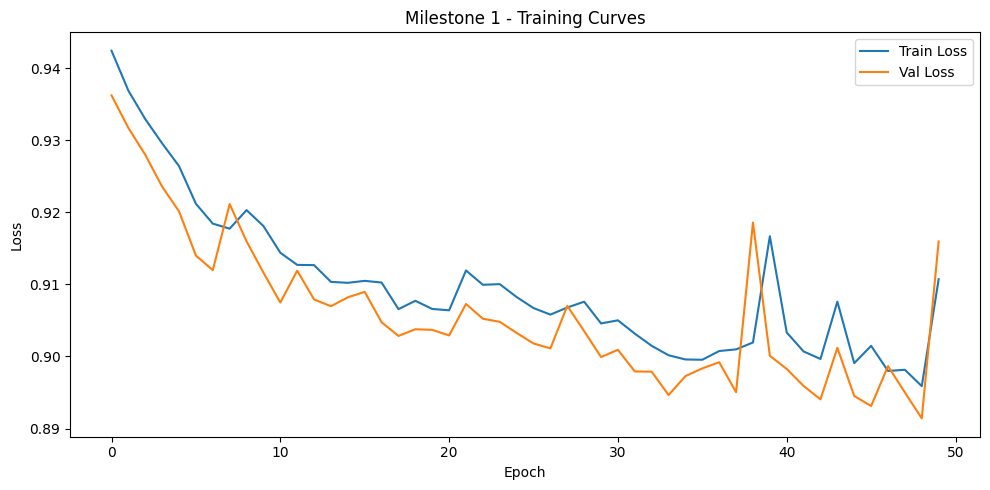

In [10]:
checkpoint = torch.load(CHECKPOINT_PATH)
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Milestone 1 - Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve_m1.png')
plt.show()

In [11]:
print(f'train_losses={train_losses}')
print(f'val_losses={val_losses}')

train_losses=[0.9424147187344265, 0.9368738788714112, 0.9329247890823564, 0.929562590251746, 0.9264007316268905, 0.9211823587686243, 0.9184264880070984, 0.9177260236960781, 0.9203005611776586, 0.9180898141093418, 0.9143869971605374, 0.9127037983305257, 0.9126695038327269, 0.9103461172978883, 0.9102125968971483, 0.9104851539465982, 0.9102536532240855, 0.9065593401910793, 0.9077191433196576, 0.906587469505832, 0.9063977733464308, 0.9119258262741734, 0.9099430120447032, 0.9100281251987941, 0.9082381492649285, 0.9067096307244099, 0.9058035714045857, 0.9067833000265616, 0.9075907327279719, 0.9045786683708129, 0.9050101022605205, 0.9031606997762408, 0.9014718615313171, 0.9001647200382931, 0.8995772885604644, 0.8995407891705243, 0.9007491401023788, 0.9009787736524278, 0.9019353928220584, 0.9166660963649481, 0.9033215433299182, 0.9006892328770828, 0.8996475141053228, 0.9076013802522624, 0.8990684040115633, 0.9014680229682078, 0.8979875628857066, 0.8981482630044642, 0.8958795834595049, 0.910710

### Visualization

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


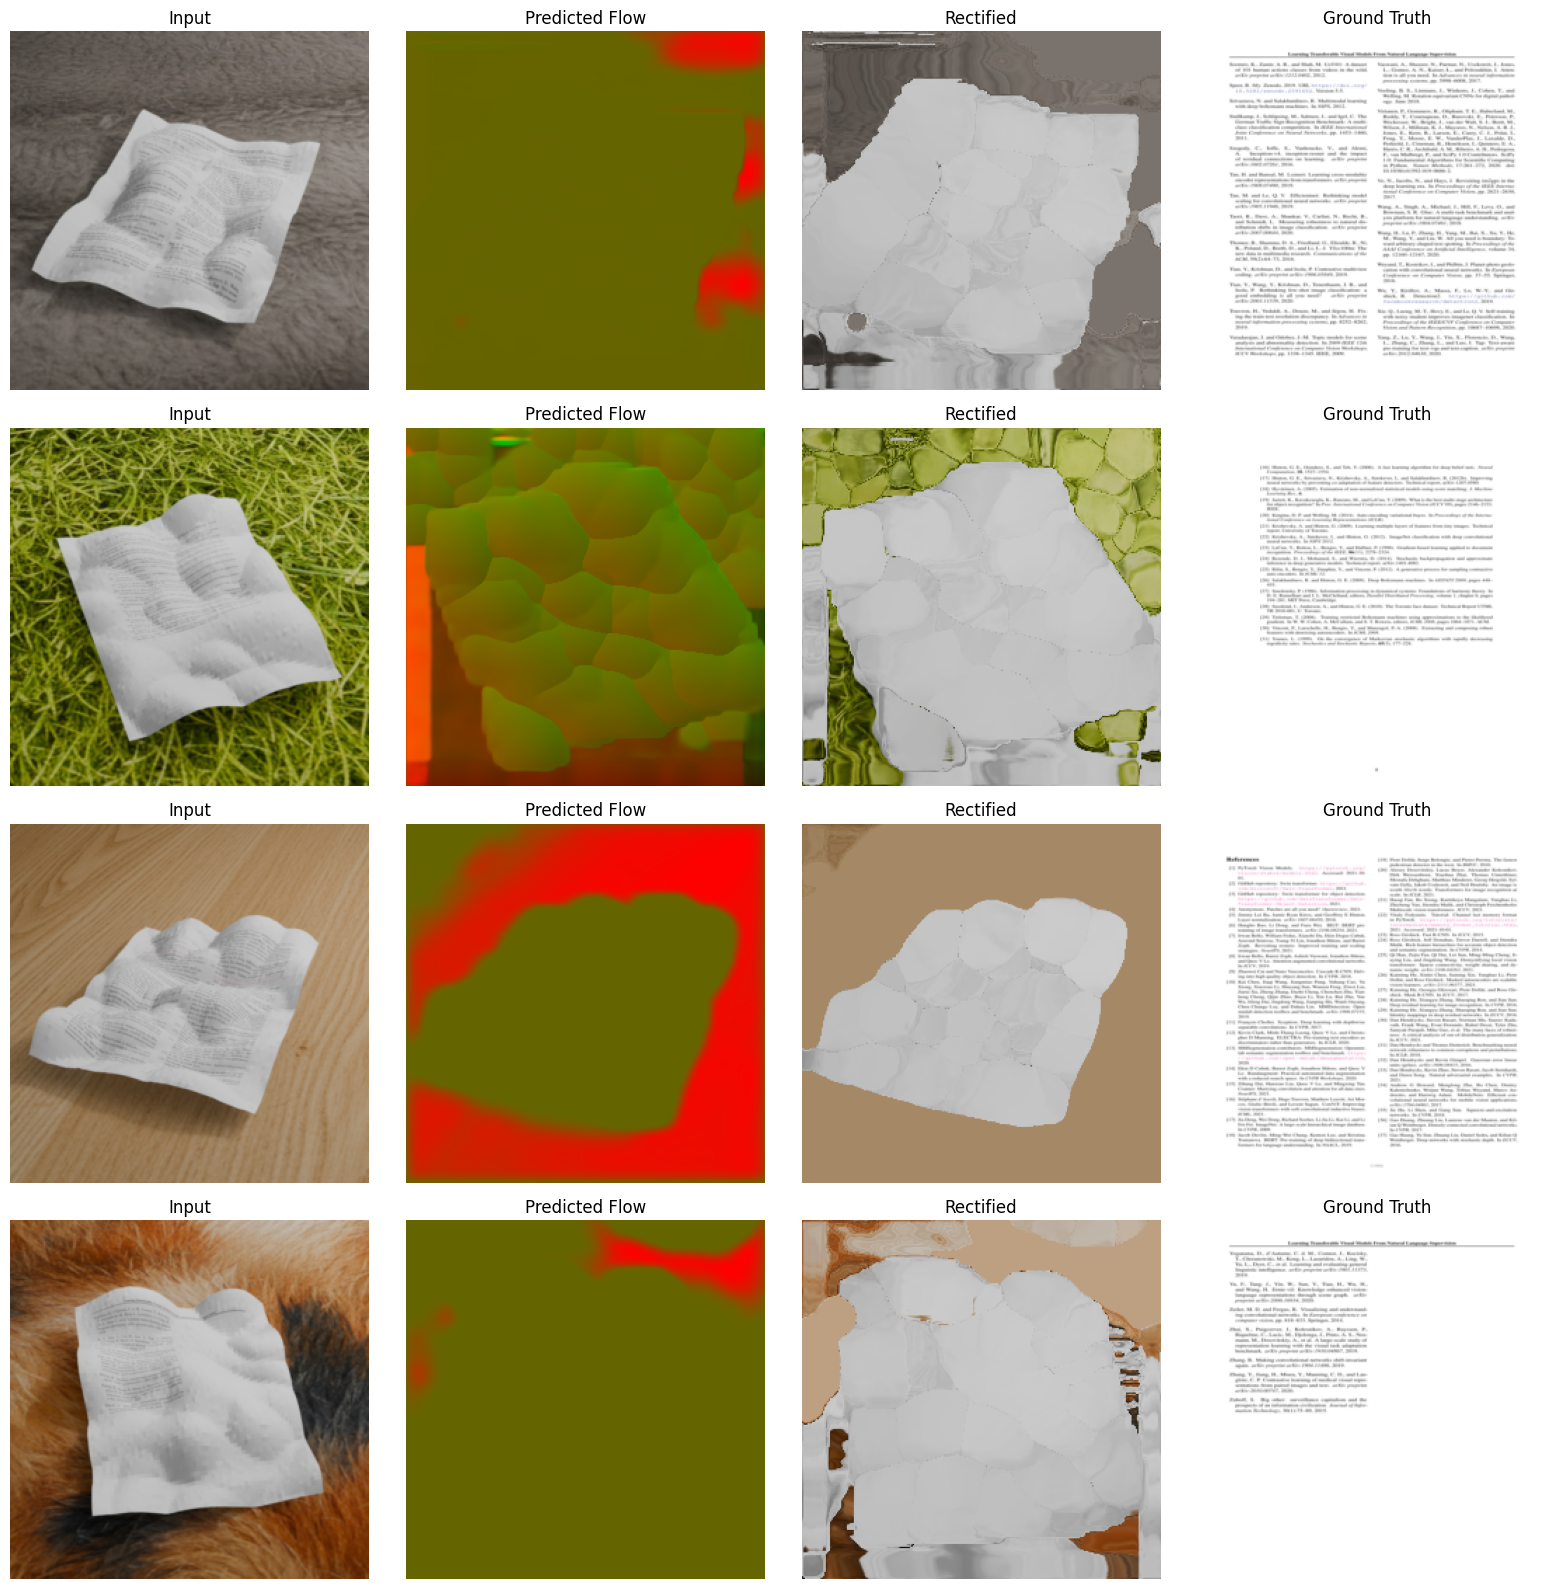

In [23]:
# Load model
model = SimpleEncoderDecoder().to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

# Get a batch from val loader
batch = next(iter(val_loader))
rgb = batch['rgb'].to(device)
ground_truth = batch['ground_truth'].to(device)

with torch.no_grad():
    rectified, flow = model(rgb)

# Denormalize for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

def denorm(t):
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

def viz_flow(f):
    # Normalize flow to [0,1] for visualization
    f = f.cpu().numpy()
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    return np.transpose(f, (1, 2, 0))  # [H, W, 2] - just show 2 channels as RG

# Plot 4 samples
n = 4
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

for i in range(n):
    axes[i, 0].imshow(denorm(rgb[i]))
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    flow_vis = viz_flow(flow[i])
    axes[i, 1].imshow(np.concatenate([flow_vis, np.zeros((*flow_vis.shape[:2], 1))], axis=-1))
    axes[i, 1].set_title('Predicted Flow')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(denorm(rectified[i]))
    axes[i, 2].set_title('Rectified')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(denorm(ground_truth[i]))
    axes[i, 3].set_title('Ground Truth')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('visualization_m1.png')
plt.show()

## Milestone 2, Pretrained backbone

In [11]:
model = DocumentDewarpNet().to(device)
criterion = SSIMLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model parameters: 40,743,010


In [12]:
CHECKPOINT_DIR = '/content/drive/MyDrive/tufts/cs 132 computer vision/'
CHECKPOINT_PATH = CHECKPOINT_DIR + 'checkpoint_m2.pth'
BEST_MODEL_PATH = CHECKPOINT_DIR + 'best_model_m2.pth'

In [13]:
NUM_EPOCHS=50

In [14]:
# Load checkpoint if it exists (for resuming)
start_epoch = 0
train_losses_m2 = []
val_losses_m2 = []
best_val_loss_m2 = float('inf')

if os.path.exists(CHECKPOINT_PATH):
    print("Resuming from checkpoint...")
    checkpoint = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch']
    train_losses_m2 = checkpoint['train_losses']
    val_losses_m2 = checkpoint['val_losses']
    best_val_loss_m2 = checkpoint['best_val_loss']
    print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, NUM_EPOCHS):
    # Training
    model.train()
    total_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        rgb = batch['rgb'].to(device)
        ground_truth = batch['ground_truth'].to(device)

        optimizer.zero_grad()
        rectified, flow = model(rgb)
        loss = criterion(rectified, ground_truth)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses_m2.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            rgb = batch['rgb'].to(device)
            ground_truth = batch['ground_truth'].to(device)
            rectified, flow = model(rgb)
            loss = criterion(rectified, ground_truth)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses_m2.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save best model to Drive
    if avg_val_loss < best_val_loss_m2:
        best_val_loss_m2 = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Saved best model to Drive")

    # Save checkpoint to Drive every epoch
    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'train_losses': train_losses_m2,
        'val_losses': val_losses_m2,
        'best_val_loss': best_val_loss_m2,
    }, CHECKPOINT_PATH)

Resuming from checkpoint...
Resumed from epoch 16


Epoch 17/50 [Train]:   0%|          | 0/497 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 17/50 [Val]: 100%|██████████| 125/125 [00:38<00:00,  3.22it/s]


Epoch 17/50 | Train Loss: 0.7655 | Val Loss: 0.7640


Epoch 18/50 [Val]: 100%|██████████| 125/125 [00:36<00:00,  3.43it/s]


Epoch 18/50 | Train Loss: 0.7583 | Val Loss: 0.7539
  -> Saved best model to Drive


...

Epoch 48/50 | Train Loss: 0.7033 | Val Loss: 0.6920
  -> Saved best model to Drive


Epoch 49/50 [Val]: 100%|██████████| 125/125 [00:38<00:00,  3.23it/s]


Epoch 49/50 | Train Loss: 0.7034 | Val Loss: 0.6955


Epoch 50/50 [Val]: 100%|██████████| 125/125 [00:37<00:00,  3.36it/s]


Epoch 50/50 | Train Loss: 0.7021 | Val Loss: 0.7011


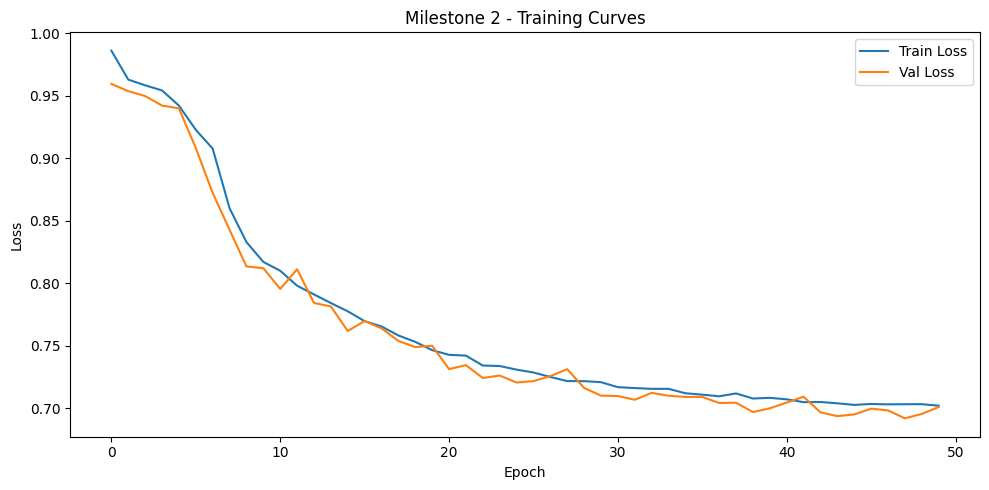

In [15]:
checkpoint = torch.load(CHECKPOINT_PATH)
train_losses_m2 = checkpoint['train_losses']
val_losses_m2 = checkpoint['val_losses']

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses_m2, label='Train Loss')
plt.plot(val_losses_m2, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Milestone 2 - Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve_m2.png')
plt.show()

In [16]:
print(f'train_losses={train_losses_m2}')
print(f'val_losses={val_losses_m2}')

train_losses=[0.9860787534377944, 0.9629725422897569, 0.9583988977629894, 0.9543189380010608, 0.9421648817283047, 0.922793717091712, 0.907768968365322, 0.8600764834664957, 0.8330202991334006, 0.8171401839381013, 0.8100710085460118, 0.7981062822898389, 0.7911363252451722, 0.7842435500991176, 0.7776421734264919, 0.7697518855273364, 0.7655143436771523, 0.75830731089686, 0.7532122275479123, 0.7465591931966709, 0.7428219750133799, 0.7421918122821171, 0.7342533930926256, 0.7338815421405692, 0.7309780309137924, 0.728687348500104, 0.7251023929603623, 0.7218210275024476, 0.7217840510354915, 0.7209463665183161, 0.7169683125896953, 0.7162351872119865, 0.7156236814541116, 0.7156395066671928, 0.7120824693674053, 0.7109609609638421, 0.7096755241963945, 0.7119467499510383, 0.7078814903495297, 0.7084212433884082, 0.7072531403430271, 0.7049693013101037, 0.7051162346747799, 0.7040396163641087, 0.7027852363749529, 0.7035209061634132, 0.7032188325820554, 0.703320275489953, 0.7033581527425969, 0.7021365497

### Visualization

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


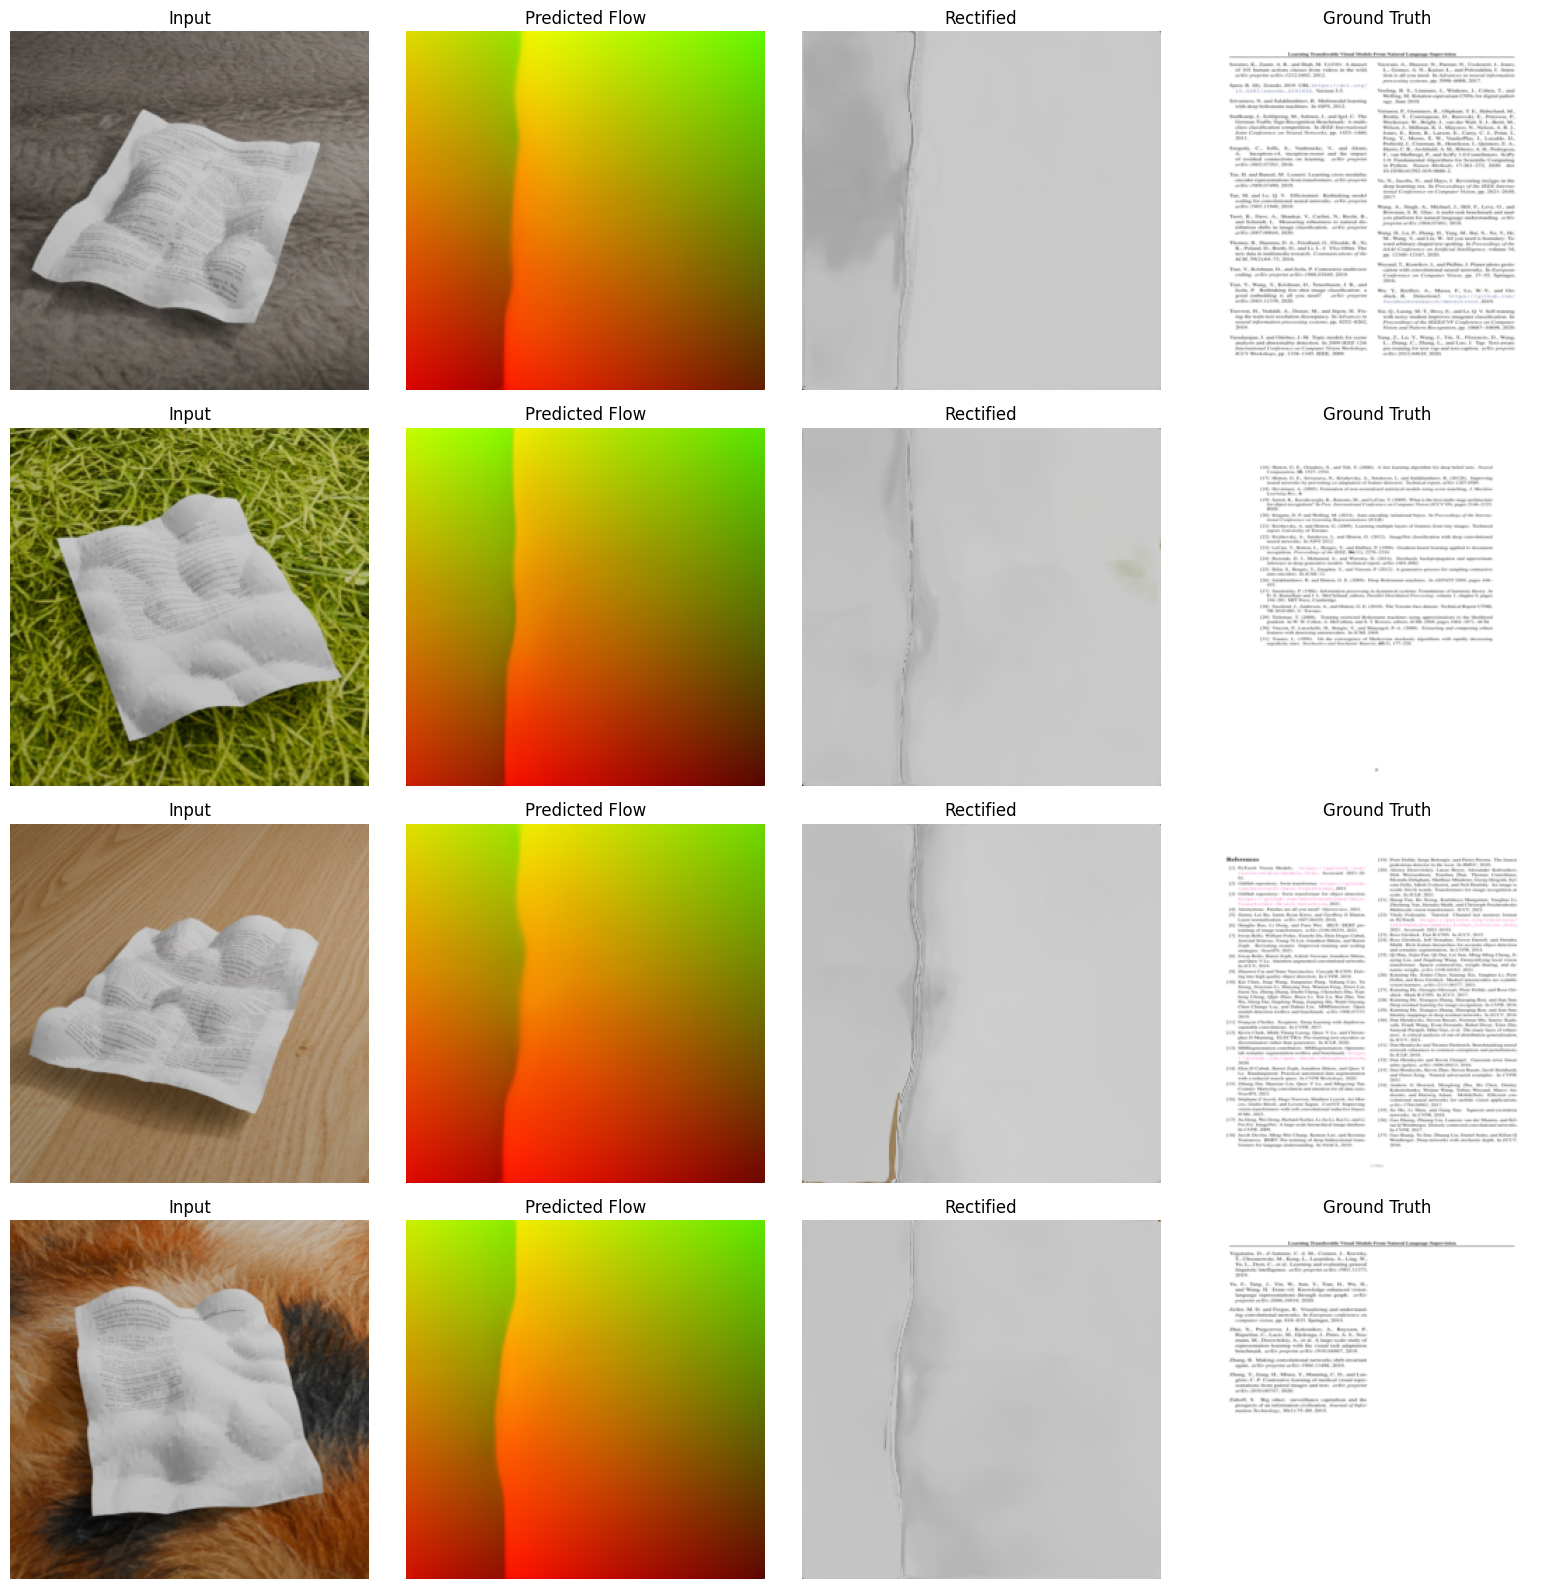

In [17]:
# Load model
model = DocumentDewarpNet().to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

# Get a batch from val loader
batch = next(iter(val_loader))
rgb = batch['rgb'].to(device)
ground_truth = batch['ground_truth'].to(device)

with torch.no_grad():
    rectified, flow = model(rgb)

# Denormalize for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

def denorm(t):
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

def viz_flow(f):
    # Normalize flow to [0,1] for visualization
    f = f.cpu().numpy()
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    return np.transpose(f, (1, 2, 0))  # [H, W, 2] - just show 2 channels as RG

# Plot 4 samples
n = 4
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

for i in range(n):
    axes[i, 0].imshow(denorm(rgb[i]))
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    flow_vis = viz_flow(flow[i])
    axes[i, 1].imshow(np.concatenate([flow_vis, np.zeros((*flow_vis.shape[:2], 1))], axis=-1))
    axes[i, 1].set_title('Predicted Flow')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(denorm(rectified[i]))
    axes[i, 2].set_title('Rectified')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(denorm(ground_truth[i]))
    axes[i, 3].set_title('Ground Truth')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('visualization_m2.png')
plt.show()